# Session 1 — Graphs, Laplacians, and where the eigenvectors go

Companion to the slides. Run every cell in order; nothing needs editing until section 7.

---
### Instructor notes

Student file plus tuning notes, cut-first markers and the numbers behind the two
data-dependent demos. Otherwise identical to `session1.ipynb`.

**Clock.** 2 — 0:10, 3 — 0:20, 4 — 0:50, 5 — 1:20, 6 — 1:45, 7 — 2:05, 8 — appendix.
Section 3 is the long one and is worth protecting; section 5 is deliberately thin.

**Cut first, in this order:** section 3's four-graph λ₂ table, section 4's eigengap
plot, section 5's Ncut comparison cell. Each is marked below. Dropping all three
buys about eight minutes and costs nothing that section 6 or 7 depends on.

**Section 7 is the only place students type.** Get them to `SIGMA` with fifteen
minutes left, not five. If the room is behind, cut section 5 entirely rather than
rushing section 6 — the map of the graph drawn over the polygons is the figure the
whole afternoon is built towards.

---

In [1]:
# Colab only. Locally this is a no-op and prints nothing.
import pathlib
import subprocess
import sys
import urllib.request

REPO_RAW = "https://raw.githubusercontent.com/farrencc/dist_net_finder/main/graph-workshop"
DATA = pathlib.Path("../data")

if "google.colab" in sys.modules:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "geopandas==1.1.4", "libpysal==4.14.1", "esda==2.9.0", "splot==1.1.7",
         "osmnx==2.1.1", "mapclassify==2.10.0"],
        check=True,
    )
    DATA = pathlib.Path("data")
    DATA.mkdir(exist_ok=True)
    for fname in ("dublin_eds.gpkg", "streets.graphml"):
        urllib.request.urlretrieve(f"{REPO_RAW}/data/{fname}", DATA / fname)
    print("Colab setup done:", sorted(p.name for p in DATA.iterdir()))

In [2]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.linalg import eigh

RNG = np.random.default_rng(20240401)
SEED = 7

plt.rcParams.update({
    "figure.figsize": (9.0, 5.0),
    "figure.dpi": 110,
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "lines.linewidth": 2.2,
    "lines.markersize": 7,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.constrained_layout.use": True,
})

import scipy
print("numpy", np.__version__, "| scipy", scipy.__version__, "| networkx", nx.__version__)
print("data directory:", DATA.resolve())

numpy 2.4.6 | scipy 1.17.1 | networkx 3.6.1
data directory: /home/user/dist_net_finder/graph-workshop/data


In [3]:
# osmnx is only needed for the cameo at 1:45. If this fails, keep going.
try:
    import osmnx as ox
    HAVE_OSMNX = True
    print("osmnx", ox.__version__)
except Exception as exc:
    HAVE_OSMNX = False
    print("osmnx unavailable:", exc)

osmnx 2.1.1


## 1 — Hook (0:00)

Slides.

## 2 — Eigenvector refresher (0:10)

$n$ unit masses in a free-free chain of unit springs. $K\mathbf{x} = \lambda \mathbf{x}$.

In [4]:
n = 6
K = np.zeros((n, n))
for i, j in [(k, k + 1) for k in range(n - 1)]:
    # one spring, four entries: it stiffens both ends and couples them with a
    # minus sign. Free-free means no spring to ground, so nothing else is added.
    K[i, i] += 1.0
    K[j, j] += 1.0
    K[i, j] -= 1.0
    K[j, i] -= 1.0

print(K.astype(int))

[[ 1 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  1]]


In [5]:
# eigh, not eig: K is symmetric. eig would hand back complex numbers with
# numerical noise in the imaginary part and eigenvectors that are not orthogonal.
vals, vecs = eigh(K)

print("eigenvalues:", np.round(vals, 10))
print("mode 0:     ", np.round(vecs[:, 0], 4))

eigenvalues: [0.         0.26794919 1.         2.         3.         3.73205081]
mode 0:      [0.4082 0.4082 0.4082 0.4082 0.4082 0.4082]


In [6]:
analytic = 2 - 2 * np.cos(np.pi * np.arange(n) / n)
print(np.column_stack([vals, analytic]).round(8))
print("max |numeric - analytic| =", np.abs(vals - analytic).max())

[[0.         0.        ]
 [0.26794919 0.26794919]
 [1.         1.        ]
 [2.         2.        ]
 [3.         3.        ]
 [3.73205081 3.73205081]]
max |numeric - analytic| = 1.5543122344752192e-15


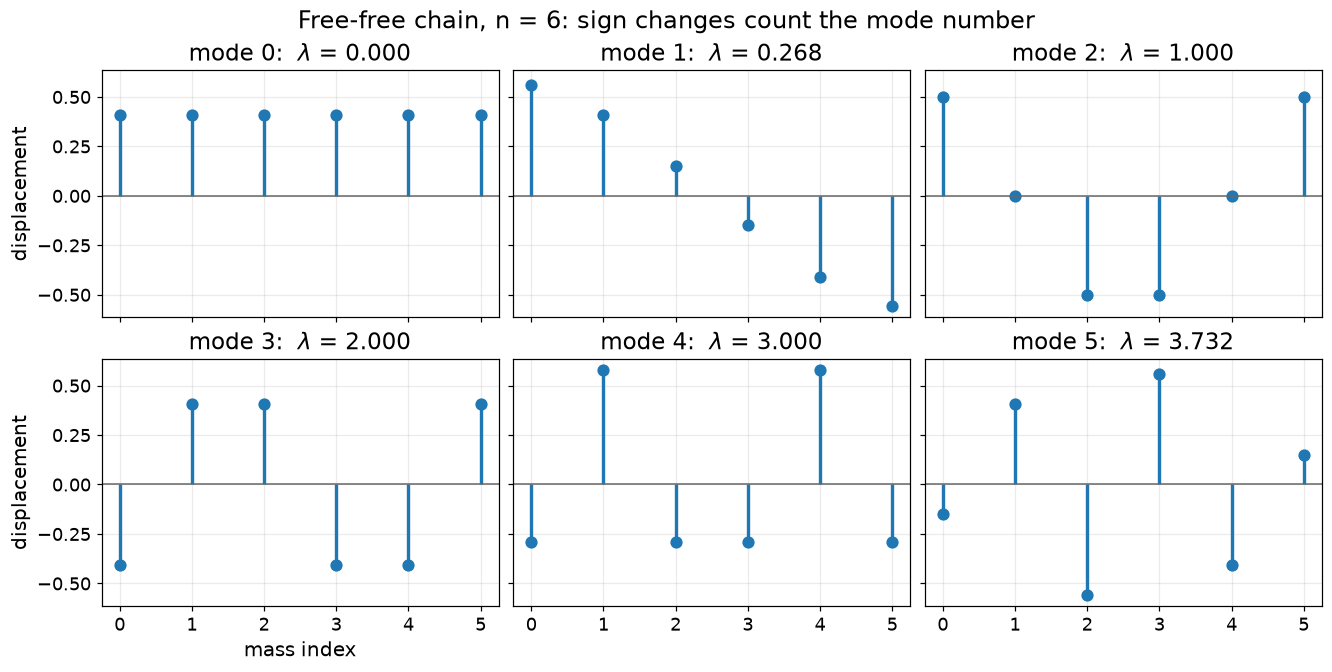

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for k, ax in enumerate(axes.ravel()):
    ax.stem(np.arange(n), vecs[:, k], basefmt=" ")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_title(rf"mode {k}:  $\lambda$ = {vals[k]:.3f}")
axes[1, 0].set_xlabel("mass index")
axes[0, 0].set_ylabel("displacement")
axes[1, 0].set_ylabel("displacement")
fig.suptitle("Free-free chain, n = 6: sign changes count the mode number")
plt.show()

In [8]:
k = 2
print("column vecs[:, k] :", np.abs(K @ vecs[:, k] - vals[k] * vecs[:, k]).max())
print("row    vecs[k, :] :", np.abs(K @ vecs[k, :] - vals[k] * vecs[k, :]).max())

column vecs[:, k] : 3.3306690738754696e-15
row    vecs[k, :] : 1.1969234250586773


In [9]:
v = vecs[:, 1]
print("v  residual:", np.abs(K @ v - vals[1] * v).max())
print("-v residual:", np.abs(K @ (-v) - vals[1] * (-v)).max())
print("first entry of v:", v[0], " of -v:", -v[0])

v  residual: 4.468647674116255e-15
-v residual: 4.468647674116255e-15
first entry of v: 0.55767753582521  of -v: -0.55767753582521


Degeneracy: any rotation inside a repeated eigenspace is also an eigenvector, so
LAPACK's choice of basis there is arbitrary and not reproducible across versions.

In [10]:
L_ring = nx.laplacian_matrix(nx.cycle_graph(6)).toarray().astype(float)
print(np.round(eigh(L_ring, eigvals_only=True), 10))

[-0.  1.  1.  3.  3.  4.]


## 3 — Laplacian (0:20)

$L = D - A$, and $\mathbf{x}^{\top} L \mathbf{x} = \sum_{(i,j) \in E} (x_i - x_j)^2$.

In [11]:
L_path = nx.laplacian_matrix(nx.path_graph(6)).toarray()
print(L_path)
print("same matrix as the spring chain:", np.array_equal(L_path, K.astype(int)))

[[ 1 -1  0  0  0  0]
 [-1  2 -1  0  0  0]
 [ 0 -1  2 -1  0  0]
 [ 0  0 -1  2 -1  0]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0  0 -1  1]]
same matrix as the spring chain: True


In [12]:
edges = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)]
G = nx.Graph(edges)
nodes = list(range(6))

A = nx.adjacency_matrix(G, nodelist=nodes).toarray()
D = np.diag(A.sum(axis=1))
L = D - A

print("A =\n", A)
print("degrees =", A.sum(axis=1))
print("L =\n", L)
print("row sums =", L.sum(axis=1))

A =
 [[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 0 0]
 [0 0 1 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]
degrees = [2 2 3 3 2 2]
L =
 [[ 2 -1 -1  0  0  0]
 [-1  2 -1  0  0  0]
 [-1 -1  3 -1  0  0]
 [ 0  0 -1  3 -1 -1]
 [ 0  0  0 -1  2 -1]
 [ 0  0  0 -1 -1  2]]
row sums = [0 0 0 0 0 0]


In [13]:
edge_list = sorted(tuple(sorted(e)) for e in G.edges())
B = np.zeros((len(edge_list), len(nodes)))
for e, (i, j) in enumerate(edge_list):
    B[e, i] = -1.0   # tail
    B[e, j] = +1.0   # head
    # the head/tail choice is bookkeeping. The graph is undirected; we are
    # picking an orientation only so that a difference has a sign.

print("edges:", edge_list)
print(B.astype(int))

edges: [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4), (3, 5), (4, 5)]
[[-1  1  0  0  0  0]
 [-1  0  1  0  0  0]
 [ 0 -1  1  0  0  0]
 [ 0  0 -1  1  0  0]
 [ 0  0  0 -1  1  0]
 [ 0  0  0 -1  0  1]
 [ 0  0  0  0 -1  1]]


In [14]:
x = np.array([3.0, 1.0, 4.0, 1.0, 5.0, 9.0])
for (i, j), d in zip(edge_list, B @ x):
    print(f"edge ({i},{j}):  x[{j}] - x[{i}] = {d:+.0f}")

edge (0,1):  x[1] - x[0] = -2
edge (0,2):  x[2] - x[0] = +1
edge (1,2):  x[2] - x[1] = +3
edge (2,3):  x[3] - x[2] = -3
edge (3,4):  x[4] - x[3] = +4
edge (3,5):  x[5] - x[3] = +8
edge (4,5):  x[5] - x[4] = +4


In [15]:
print("B^T B == D - A                :", np.array_equal(B.T @ B, L))
print("B^T B == nx.laplacian_matrix  :",
      np.array_equal(B.T @ B, nx.laplacian_matrix(G, nodelist=nodes).toarray()))

B^T B == D - A                : True
B^T B == nx.laplacian_matrix  : True


In [16]:
print("x^T L x        =", x @ L @ x)
print("||B x||^2      =", np.sum((B @ x) ** 2))
print("sum (xi - xj)^2 =", sum((x[i] - x[j]) ** 2 for i, j in edge_list))

x^T L x        = 119.0
||B x||^2      = 119.0
sum (xi - xj)^2 = 119.0


In [17]:
B_flipped = B.copy()
B_flipped[[0, 4]] *= -1

print("B changed        :", not np.array_equal(B_flipped, B))
print("B^T B unchanged  :", np.array_equal(B_flipped.T @ B_flipped, L))

B changed        : True
B^T B unchanged  : True


In [18]:
for s in [np.array([1.0, 1.0, 1.0, -1.0, -1.0, -1.0]),
          np.array([1.0, -1.0, 1.0, -1.0, 1.0, -1.0])]:
    cut = sum(1 for i, j in edge_list if s[i] != s[j])
    print(f"s = {s.astype(int)}   s^T L s = {s @ L @ s:5.0f}   4 x cut = {4 * cut:5d}")

s = [ 1  1  1 -1 -1 -1]   s^T L s =     4   4 x cut =     4
s = [ 1 -1  1 -1  1 -1]   s^T L s =    20   4 x cut =    20


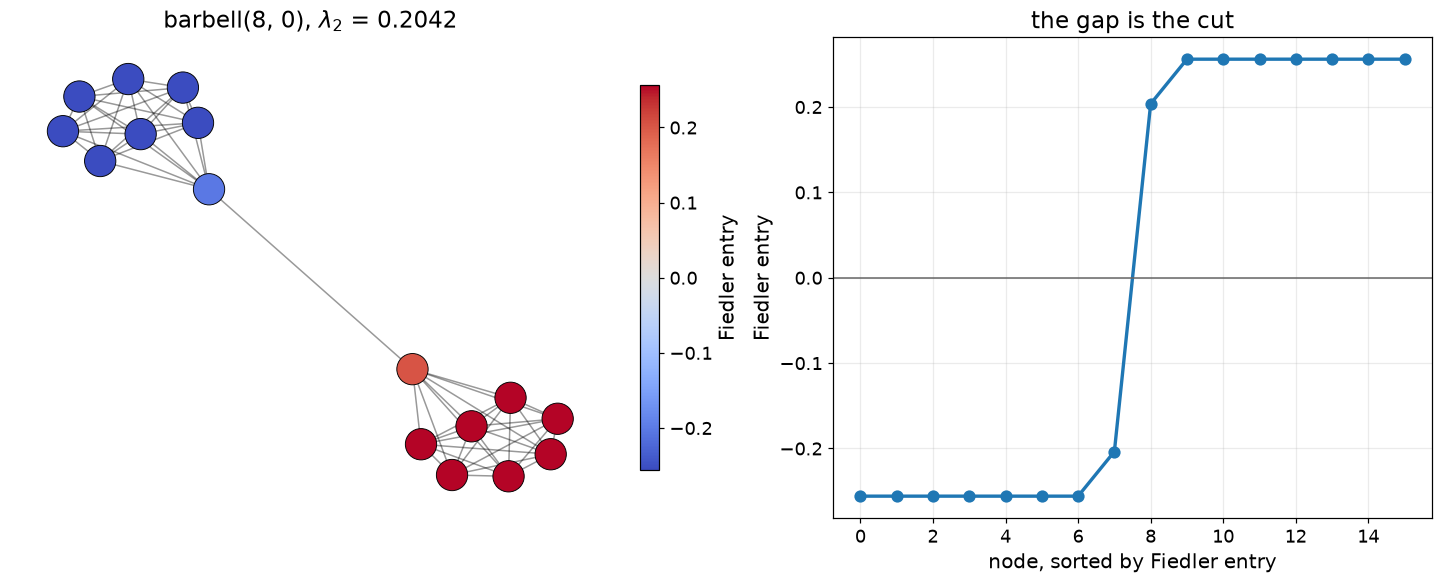

In [19]:
Gb = nx.barbell_graph(8, 0)
Lb = nx.laplacian_matrix(Gb).toarray().astype(float)
vals_b, vecs_b = eigh(Lb)
fiedler = vecs_b[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
pos = nx.spring_layout(Gb, seed=SEED)
nx.draw_networkx_edges(Gb, pos, ax=ax1, alpha=0.4)
sc = nx.draw_networkx_nodes(Gb, pos, ax=ax1, node_color=fiedler, cmap="coolwarm",
                            node_size=420, edgecolors="k", linewidths=0.6)
ax1.set_axis_off()
ax1.set_title(rf"barbell(8, 0), $\lambda_2$ = {vals_b[1]:.4f}")
fig.colorbar(sc, ax=ax1, shrink=0.8, label="Fiedler entry")

ax2.plot(np.sort(fiedler), "o-")
ax2.axhline(0, color="0.4", lw=1)
ax2.set_xlabel("node, sorted by Fiedler entry")
ax2.set_ylabel("Fiedler entry")
ax2.set_title("the gap is the cut")
plt.show()

**Cut first if behind.** The four-graph λ₂ table restates what the barbell figure already showed.

In [20]:
for name, g in [
    ("barbell(8,0)", nx.barbell_graph(8, 0)),
    ("path(16)", nx.path_graph(16)),
    ("ring(16)", nx.cycle_graph(16)),
    ("complete(16)", nx.complete_graph(16)),
]:
    lam = eigh(nx.laplacian_matrix(g).toarray().astype(float), eigvals_only=True)
    print(f"{name:14s}  lambda_2 = {lam[1]:8.4f}")

barbell(8,0)    lambda_2 =   0.2042
path(16)        lambda_2 =   0.0384
ring(16)        lambda_2 =   0.1522
complete(16)    lambda_2 =  16.0000


---
**Tuning note — section 4, the pendant graph.**

`N_BIG = 12`, `N_SMALL = 4`, `N_BRIDGE = 3`. The bridge multiplicity is the tuned
parameter and it is load-bearing in both directions:

- With a single bridge edge there are two minimum cuts of size 1 and
  `nx.minimum_edge_cut` returns the bridge, not the pendant. The MinCut cell then
  makes no point at all.
- With four bridge edges the discrete RatioCut of the pendant split (1.062) drops
  below the bridge split, so RatioCut genuinely prefers to lop the pendant off and
  the "balancing term rescues you" story is false.

Three is the value where the minimum cut is uniquely the pendant edge, RatioCut still
rejects it (1.062 against 0.981 — narrowly, which is the point), and Ncut rejects it
emphatically (1.007 against 0.222).

The two Fiedler vectors give the same sign split. The visible difference is what
happens to the pendant: RatioCut sends it to the extreme of the vector, Ncut leaves it
sitting on top of the big clique, because a degree-1 node carries no volume and so
cannot help balance an Ncut. That contrast is what the two-panel figure is for — say
it out loud, because the sign split alone will not show it.

---

## 4 — Spectral clustering (0:50)

$\mathrm{RatioCut}(A,\bar A) = \mathrm{cut}\left(\tfrac{1}{|A|} + \tfrac{1}{|\bar A|}\right)$,
$\;\mathrm{Ncut}(A,\bar A) = \mathrm{cut}\left(\tfrac{1}{\mathrm{vol}\,A} + \tfrac{1}{\mathrm{vol}\,\bar A}\right)$.

In [21]:
N_BIG, N_SMALL, N_BRIDGE = 12, 4, 3

big = list(range(N_BIG))
small = list(range(N_BIG, N_BIG + N_SMALL))
PENDANT = N_BIG + N_SMALL

Gp = nx.Graph()
Gp.add_edges_from(nx.complete_graph(big).edges())
Gp.add_edges_from(nx.complete_graph(small).edges())
for k in range(N_BRIDGE):
    Gp.add_edge(big[-1 - k], small[k])
Gp.add_edge(big[0], PENDANT)

min_cut = nx.minimum_edge_cut(Gp)
torn = Gp.copy()
torn.remove_edges_from(min_cut)

print("minimum edge cut:", sorted(min_cut))
print("component sizes :", sorted(len(c) for c in nx.connected_components(torn)))

minimum edge cut: [(16, 0)]
component sizes : [1, 16]


In [22]:
def cut_scores(g, side):
    side = set(side)
    other = set(g) - side
    cut = sum(1 for i, j in g.edges() if (i in side) != (j in side))
    vol_s = sum(d for _, d in g.degree(side))
    vol_o = sum(d for _, d in g.degree(other))
    return cut, cut * (1 / len(side) + 1 / len(other)), cut * (1 / vol_s + 1 / vol_o)


print(f"{'split':>16s} {'cut':>5s} {'RatioCut':>10s} {'Ncut':>10s}")
for label, side in [("pendant alone", [PENDANT]), ("at the bridge", small)]:
    c, rc, nc = cut_scores(Gp, side)
    print(f"{label:>16s} {c:5d} {rc:10.3f} {nc:10.4f}")

           split   cut   RatioCut       Ncut
   pendant alone     1      1.062     1.0066
   at the bridge     3      0.981     0.2219


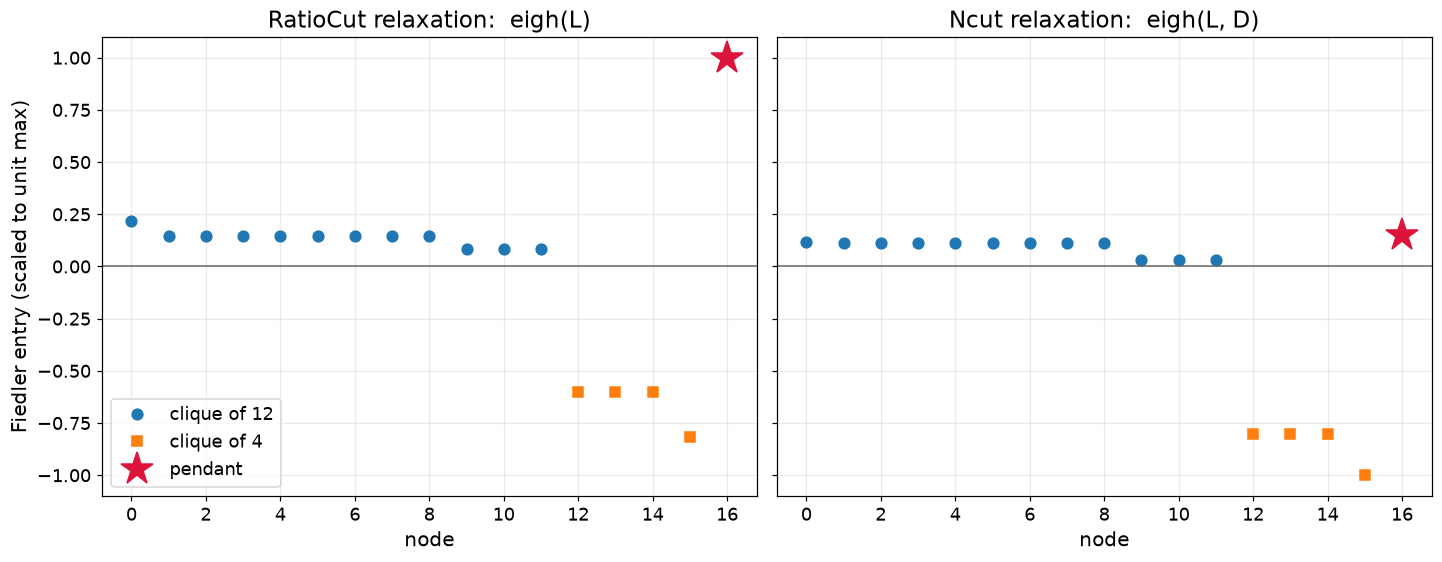

In [23]:
Lp = nx.laplacian_matrix(Gp, nodelist=sorted(Gp)).toarray().astype(float)
Dp = np.diag([Gp.degree(v) for v in sorted(Gp)]).astype(float)

f_ratio = eigh(Lp)[1][:, 1]
f_ncut = eigh(Lp, Dp)[1][:, 1]

# both are defined up to sign and scale; fix both so the panels are comparable
f_ratio = f_ratio / np.abs(f_ratio).max() * np.sign(f_ratio[PENDANT])
f_ncut = f_ncut / np.abs(f_ncut).max() * np.sign(f_ncut[PENDANT])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, f, title in [(axes[0], f_ratio, "RatioCut relaxation:  eigh(L)"),
                     (axes[1], f_ncut, "Ncut relaxation:  eigh(L, D)")]:
    ax.plot(big, f[big], "o", label=f"clique of {N_BIG}")
    ax.plot(small, f[small], "s", label=f"clique of {N_SMALL}")
    ax.plot([PENDANT], [f[PENDANT]], "*", ms=22, color="crimson", label="pendant")
    ax.axhline(0, color="0.4", lw=1)
    ax.set_xlabel("node")
    ax.set_title(title)
axes[0].set_ylabel("Fiedler entry (scaled to unit max)")
axes[0].legend(loc="lower left")
plt.show()

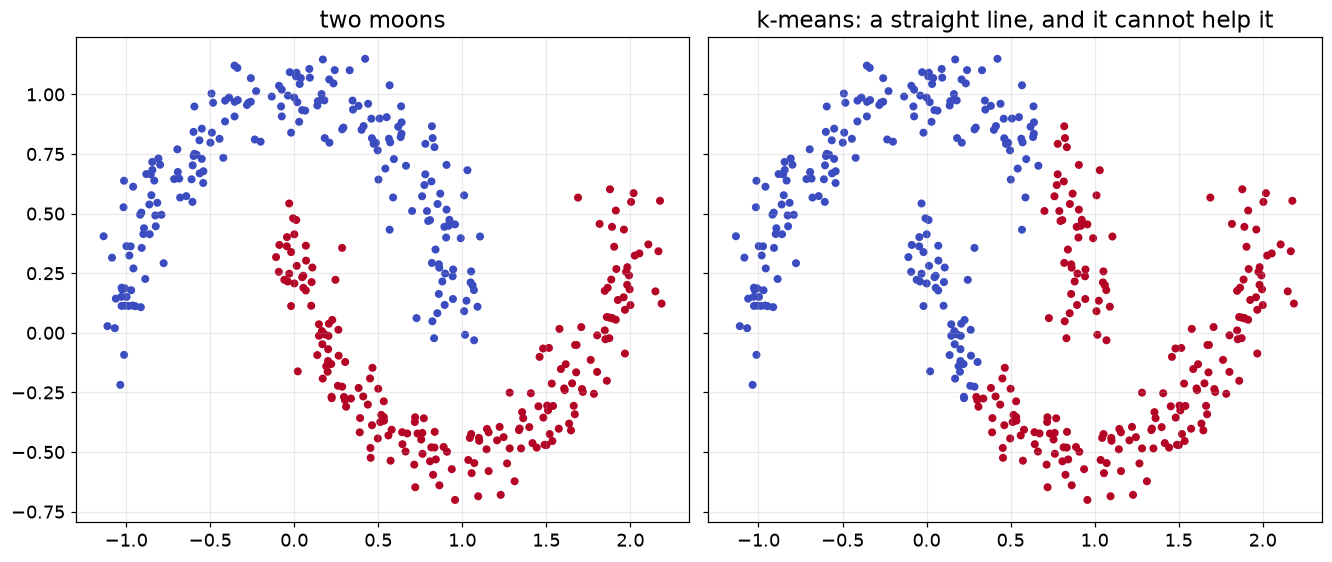

In [24]:
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.datasets import make_moons

X, y_true = make_moons(n_samples=400, noise=0.10, random_state=SEED)
y_km = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(X)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
ax1.scatter(*X.T, c=y_true, cmap="coolwarm", s=18)
ax1.set_title("two moons")
ax2.scatter(*X.T, c=y_km, cmap="coolwarm", s=18)
ax2.set_title("k-means: a straight line, and it cannot help it")
plt.show()

In [25]:
from sklearn.neighbors import kneighbors_graph

K_NN = 12
k = 2

# kNN is not a symmetric relation: i can be among j's ten nearest without j
# being among i's. Symmetrise before calling it an adjacency matrix, or L is
# not symmetric and eigh is meaningless.
Aknn = kneighbors_graph(X, K_NN, mode="connectivity", include_self=False).toarray()
Aknn = np.maximum(Aknn, Aknn.T)

Dm = np.diag(Aknn.sum(axis=1))
Lm = Dm - Aknn
vals_m, vecs_m = eigh(Lm, Dm)
U = vecs_m[:, :k]
y_spec = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(U)

print("kNN graph connected:", nx.is_connected(nx.from_numpy_array(Aknn)))
print("first eigenvalues:", np.round(vals_m[:5], 6))

kNN graph connected: True
first eigenvalues: [-0.        0.000405  0.003274  0.004238  0.012788]


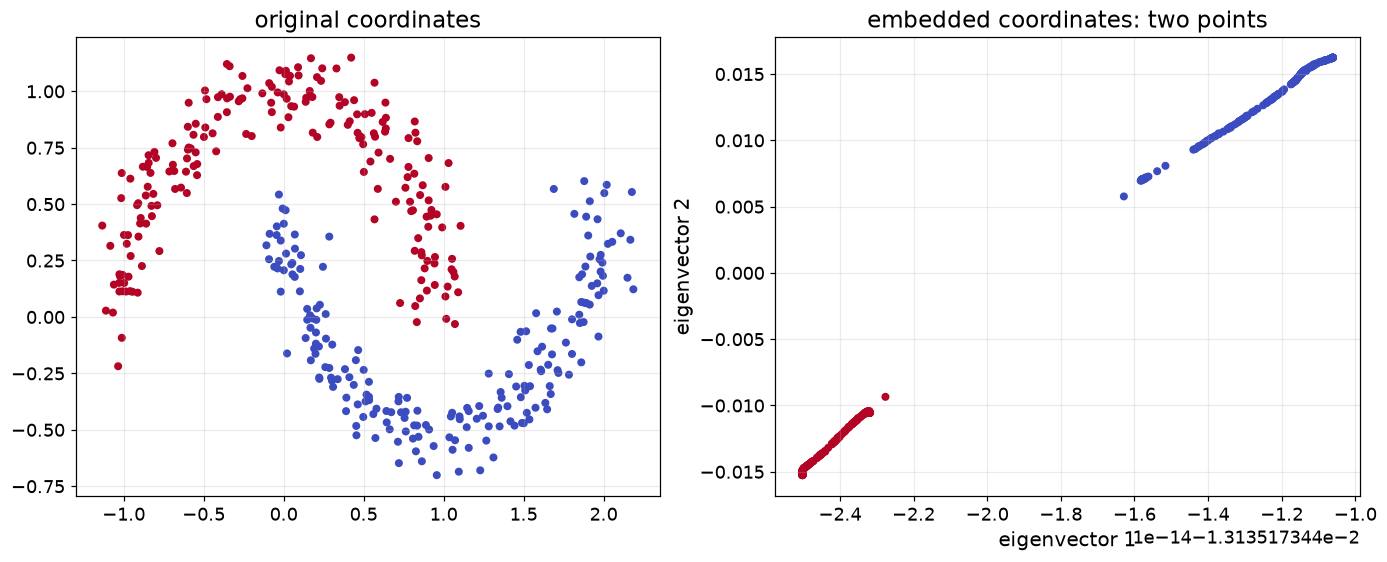

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))
ax1.scatter(*X.T, c=y_spec, cmap="coolwarm", s=18)
ax1.set_title("original coordinates")
ax2.scatter(U[:, 0], U[:, 1], c=y_spec, cmap="coolwarm", s=18)
ax2.set_xlabel("eigenvector 1")
ax2.set_ylabel("eigenvector 2")
ax2.set_title("embedded coordinates: two points")
plt.show()

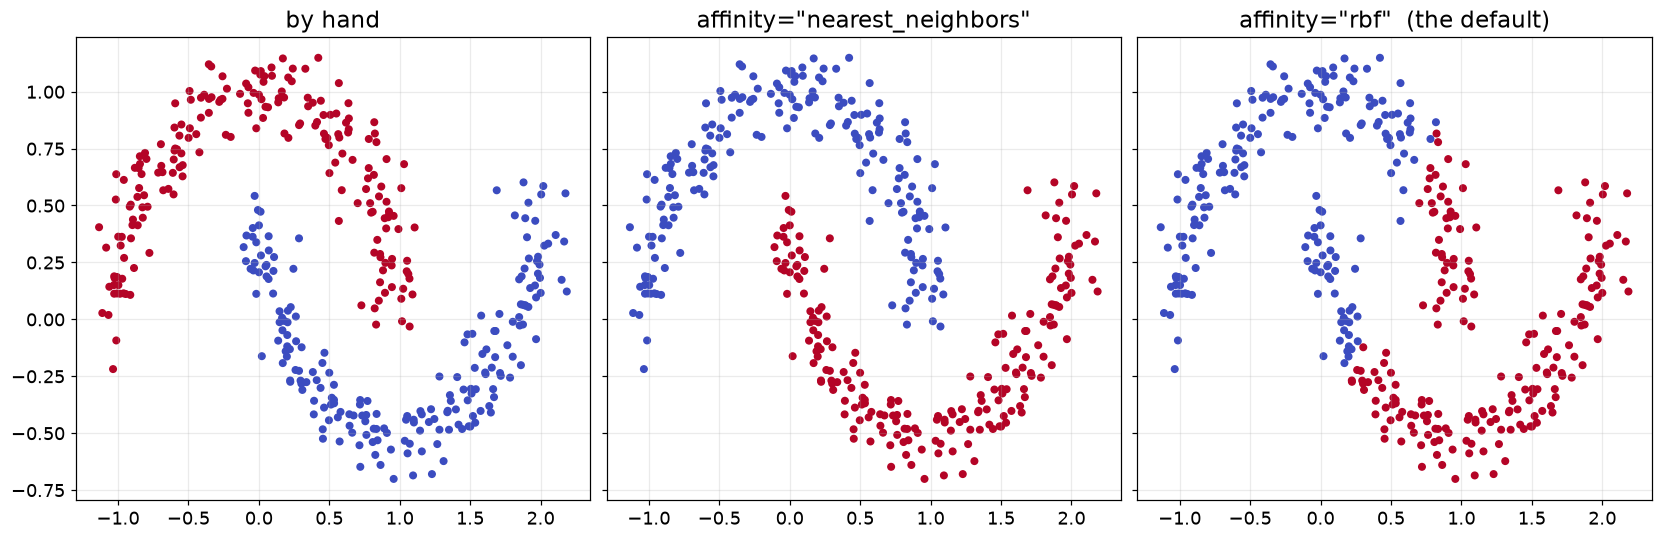

In [27]:
y_nn = SpectralClustering(n_clusters=2, affinity="nearest_neighbors",
                          n_neighbors=K_NN, random_state=SEED,
                          assign_labels="kmeans").fit_predict(X)
y_rbf = SpectralClustering(n_clusters=2, affinity="rbf",
                           random_state=SEED, assign_labels="kmeans").fit_predict(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)
for ax, lab, title in [(axes[0], y_spec, "by hand"),
                       (axes[1], y_nn, 'affinity="nearest_neighbors"'),
                       (axes[2], y_rbf, 'affinity="rbf"  (the default)')]:
    ax.scatter(*X.T, c=lab, cmap="coolwarm", s=18)
    ax.set_title(title)
plt.show()

**Cut first if behind.** The eigengap plot. Worth showing if there is time; nothing later needs it.

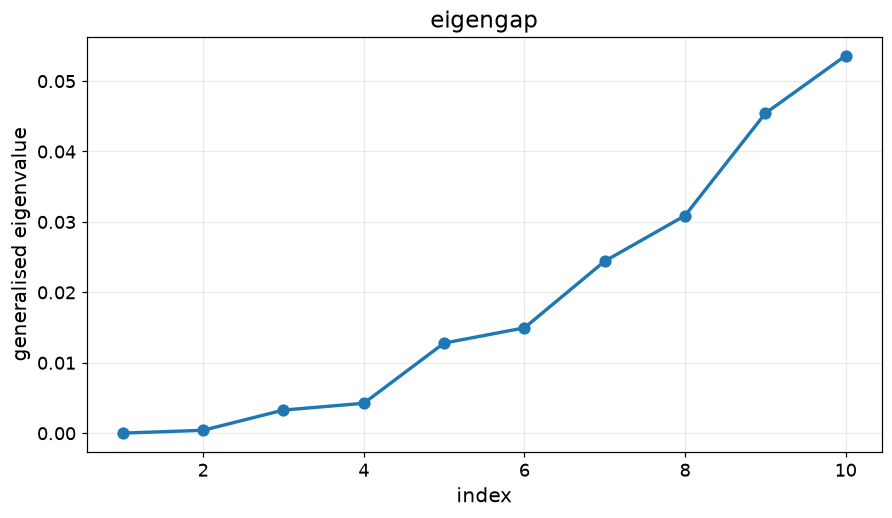

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.plot(np.arange(1, 11), vals_m[:10], "o-")
ax.set_xlabel("index")
ax.set_ylabel("generalised eigenvalue")
ax.set_title("eigengap")
plt.show()

---
**Tuning note — section 5, the block model.**

`SIZES = [60, 60, 20]`, `P_IN = 0.20`, `P_CROSS = 0.004`, `P_BORDER_OUT = 0.12`,
`P_BORDER_IN = 0.02`, `seed = 7`.

The border block is deliberately *sparser inside* than the two large blocks and
reasonably well connected to both. That makes it a border rather than a community, and
Louvain has no choice but to tear it in half: two communities, 70 and 70, modularity
0.385, with the twenty border nodes splitting ten and ten.

Raising `P_BORDER_IN` above about 0.2 flips the story — the border becomes a third
community of exactly 20 and Louvain reports three. That version is also fine to teach,
but it makes a different point, so pick one before you start. Values in between give
four or five communities with small fragments and no story at all.

`P_CROSS` has to stay near 0.004. At 0.01 the two large blocks start merging and the
confusion heatmap loses its diagonal.

---

## 5 — Community detection (1:20)

In [29]:
SIZES = [60, 60, 20]
P_IN, P_CROSS, P_BORDER_OUT, P_BORDER_IN = 0.20, 0.004, 0.12, 0.02

P = [[P_IN, P_CROSS, P_BORDER_OUT],
     [P_CROSS, P_IN, P_BORDER_OUT],
     [P_BORDER_OUT, P_BORDER_OUT, P_BORDER_IN]]

Gsbm = nx.stochastic_block_model(SIZES, P, seed=SEED)
planted = np.concatenate([np.full(s, b) for b, s in enumerate(SIZES)])

communities = nx.community.louvain_communities(Gsbm, seed=SEED)
detected = np.empty(len(planted), dtype=int)
for c, members in enumerate(communities):
    detected[list(members)] = c

border = np.bincount(detected[planted == 2], minlength=len(communities))
print(f"communities found : {len(communities)}  sizes {sorted(len(c) for c in communities)}")
print(f"modularity        : {nx.community.modularity(Gsbm, communities):.3f}")
print(f"border block of {SIZES[2]} landed in : {dict(enumerate(border))}")

communities found : 2  sizes [70, 70]
modularity        : 0.385
border block of 20 landed in : {0: np.int64(10), 1: np.int64(10)}


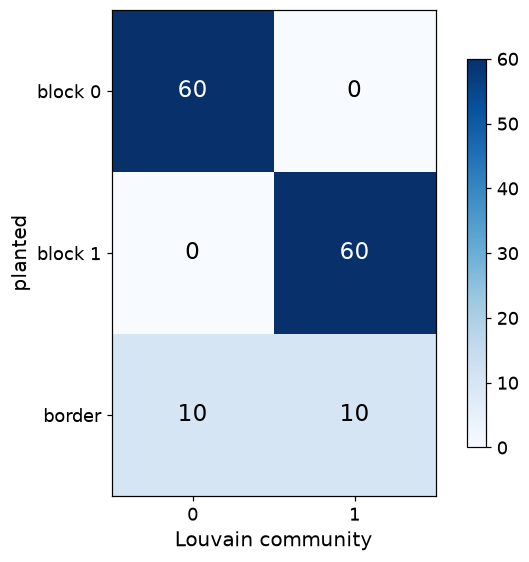

In [30]:
conf = np.zeros((len(SIZES), len(communities)), dtype=int)
for p, d in zip(planted, detected):
    conf[p, d] += 1

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(conf, cmap="Blues")
for i in range(conf.shape[0]):
    for j in range(conf.shape[1]):
        ax.text(j, i, conf[i, j], ha="center", va="center",
                color="white" if conf[i, j] > conf.max() / 2 else "black", fontsize=15)
ax.set_xticks(range(conf.shape[1]))
ax.set_yticks(range(conf.shape[0]), ["block 0", "block 1", "border"])
ax.set_xlabel("Louvain community")
ax.set_ylabel("planted")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

**Cut first if behind.** The Ncut-versus-Louvain comparison. Say the sentence instead: the two agree on all but a handful of nodes.

In [31]:
Ls = nx.laplacian_matrix(Gsbm, nodelist=sorted(Gsbm)).toarray().astype(float)
Ds = np.diag([Gsbm.degree(v) for v in sorted(Gsbm)]).astype(float)
f_sbm = eigh(Ls, Ds)[1][:, 1]
ncut_labels = (f_sbm > 0).astype(int)

agree = np.array([[np.sum((detected == c) & (ncut_labels == d))
                   for d in (0, 1)] for c in range(len(communities))])
print("Louvain (rows) against the Ncut sign split (columns):")
print(agree)

Louvain (rows) against the Ncut sign split (columns):
[[ 3 67]
 [68  2]]


## 6 — Geospatial (1:45)

In [32]:
import geopandas as gpd
from libpysal.weights import Queen, Rook

ATTR = "pct_third_level"

gdf = gpd.read_file(DATA / "dublin_eds.gpkg", layer="eds")
print("CRS on disk :", gdf.crs.to_string(), "-", gdf.crs.name)
gdf = gdf.to_crs(2157)
print("CRS in use  :", gdf.crs.to_string(), "-", gdf.crs.name)
print(f"{len(gdf)} electoral divisions, {ATTR} from {gdf[ATTR].min():.1f} to {gdf[ATTR].max():.1f}")

CRS on disk : EPSG:2157 - IRENET95 / Irish Transverse Mercator
CRS in use  : EPSG:2157 - IRENET95 / Irish Transverse Mercator
162 electoral divisions, pct_third_level from 9.2 to 85.6


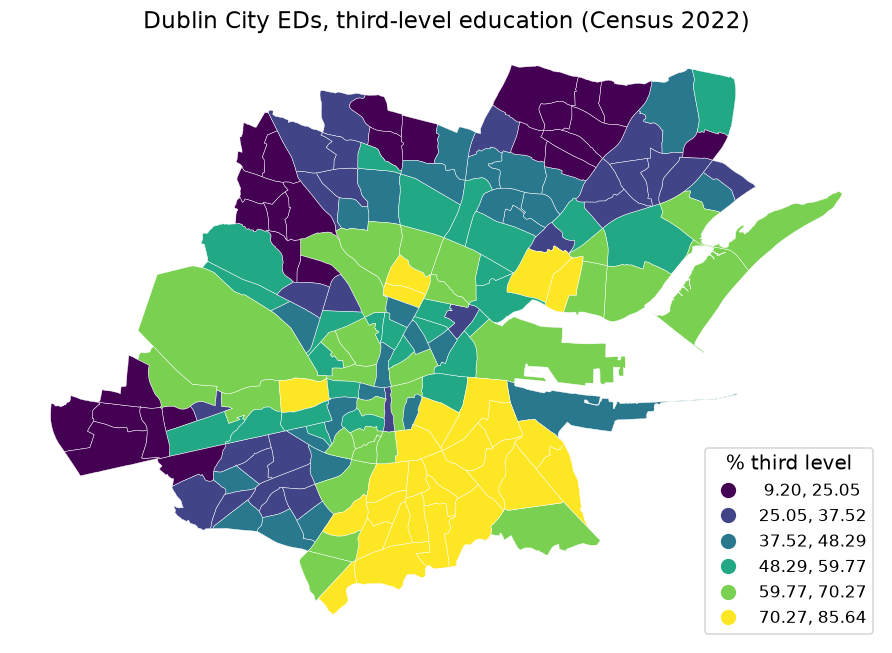

In [33]:
fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column=ATTR, cmap="viridis", scheme="quantiles", k=6,
         legend=True, edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"title": "% third level", "loc": "lower right", "fontsize": 11})
ax.set_axis_off()
ax.set_title("Dublin City EDs, third-level education (Census 2022)")
plt.show()

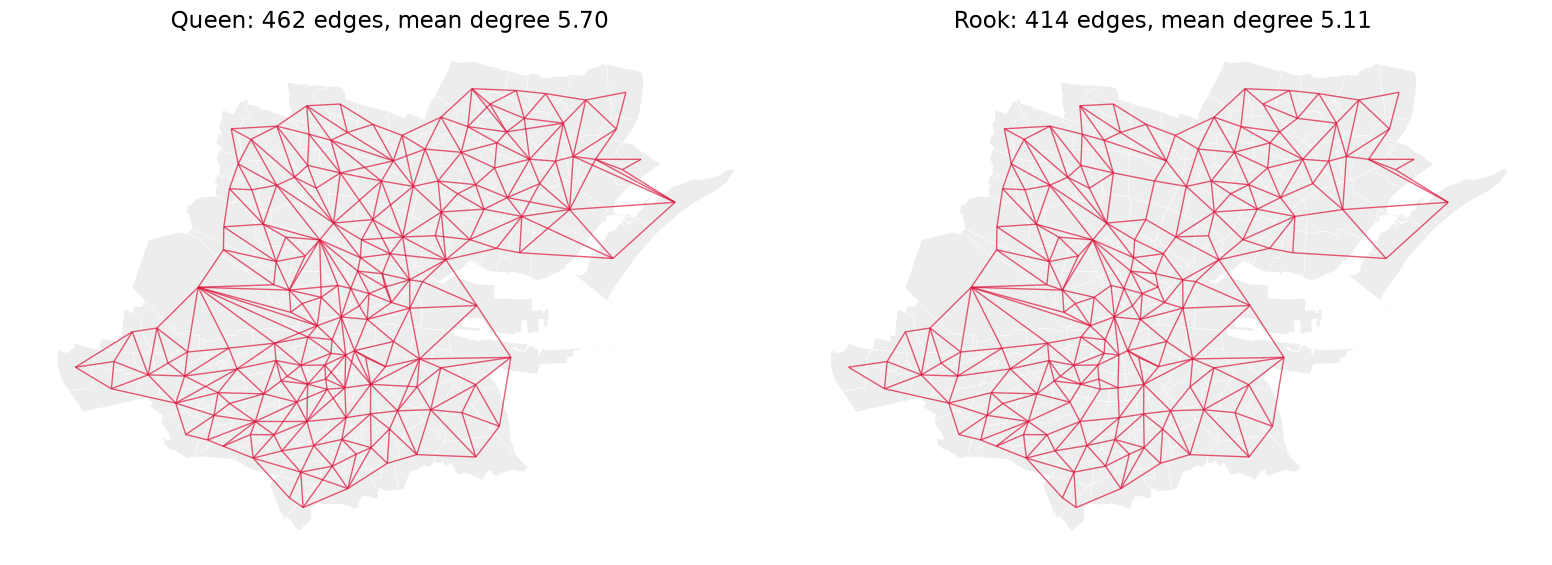

In [34]:
w_queen = Queen.from_dataframe(gdf, use_index=False)
w_rook = Rook.from_dataframe(gdf, use_index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7.5))
for ax, w, name in [(axes[0], w_queen, "Queen"), (axes[1], w_rook, "Rook")]:
    g = w.to_networkx()
    pts = {i: (p.x, p.y) for i, p in enumerate(gdf.geometry.representative_point())}
    gdf.plot(ax=ax, color="0.93", edgecolor="white", linewidth=0.3)
    nx.draw_networkx_edges(g, pts, ax=ax, edge_color="crimson", width=0.9, alpha=0.7)
    ax.set_axis_off()
    deg = np.mean([d for _, d in g.degree()])
    ax.set_title(f"{name}: {g.number_of_edges()} edges, mean degree {deg:.2f}")
plt.show()

In [35]:
G_ed = w_queen.to_networkx()
G_ed = nx.relabel_nodes(G_ed, {i: i for i in range(len(gdf))})

pts = gdf.geometry.representative_point()
POS = {i: (pts.iloc[i].x, pts.iloc[i].y) for i in range(len(gdf))}
nx.set_node_attributes(G_ed, dict(zip(range(len(gdf)), gdf[ATTR])), ATTR)
nx.set_node_attributes(G_ed, POS, "pos")
nx.set_node_attributes(G_ed, dict(zip(range(len(gdf)), gdf["ED_ENGLISH"])), "name")

assert list(G_ed.nodes()) == list(range(len(gdf))), "node order must match gdf row order"
print("nodes:", G_ed.number_of_nodes(), " edges:", G_ed.number_of_edges())
print("connected:", nx.is_connected(G_ed))
print("spot check:", [(i, G_ed.nodes[i]["name"], gdf["ED_ENGLISH"].iloc[i]) for i in (0, 80, 161)])

nodes: 162  edges: 462
connected: True
spot check: [(0, 'ARRAN QUAY A', 'ARRAN QUAY A'), (80, 'INNS QUAY B', 'INNS QUAY B'), (161, 'WOOD QUAY B', 'WOOD QUAY B')]


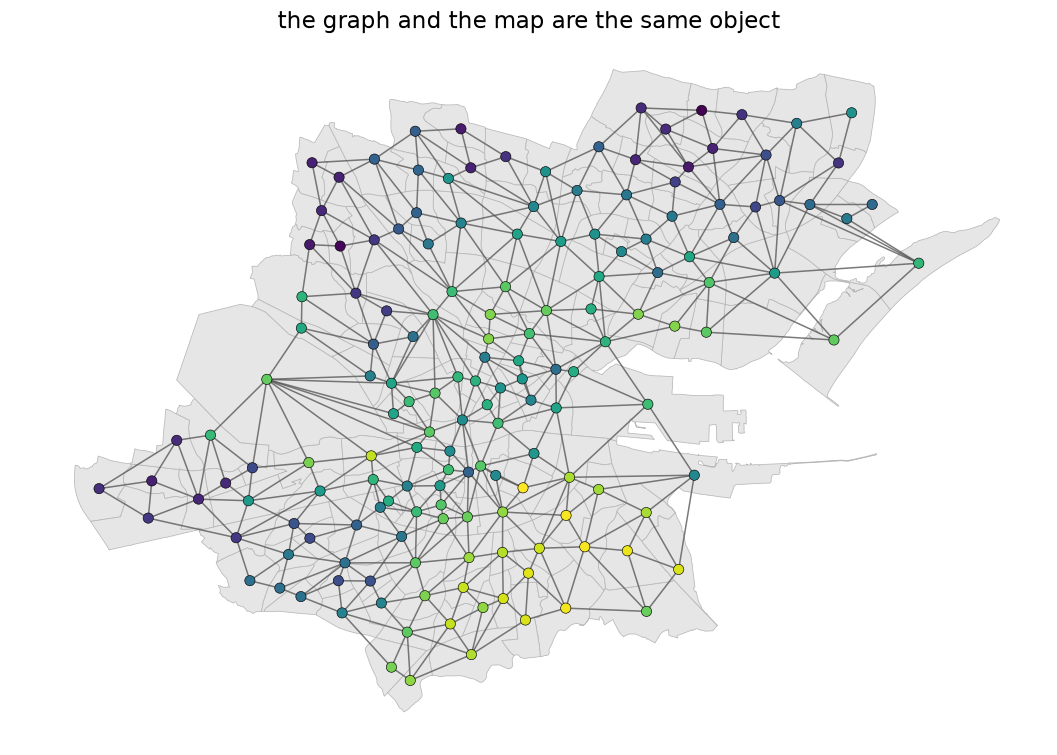

In [36]:
fig, ax = plt.subplots(figsize=(9.5, 10.5))
gdf.plot(ax=ax, color="0.90", edgecolor="0.72", linewidth=0.5)
nx.draw_networkx_edges(G_ed, POS, ax=ax, edge_color="0.35", width=1.0, alpha=0.8)
nx.draw_networkx_nodes(G_ed, POS, ax=ax, node_size=45,
                       node_color=gdf[ATTR], cmap="viridis",
                       edgecolors="k", linewidths=0.4)
ax.set_axis_off()
ax.set_title("the graph and the map are the same object")
plt.show()

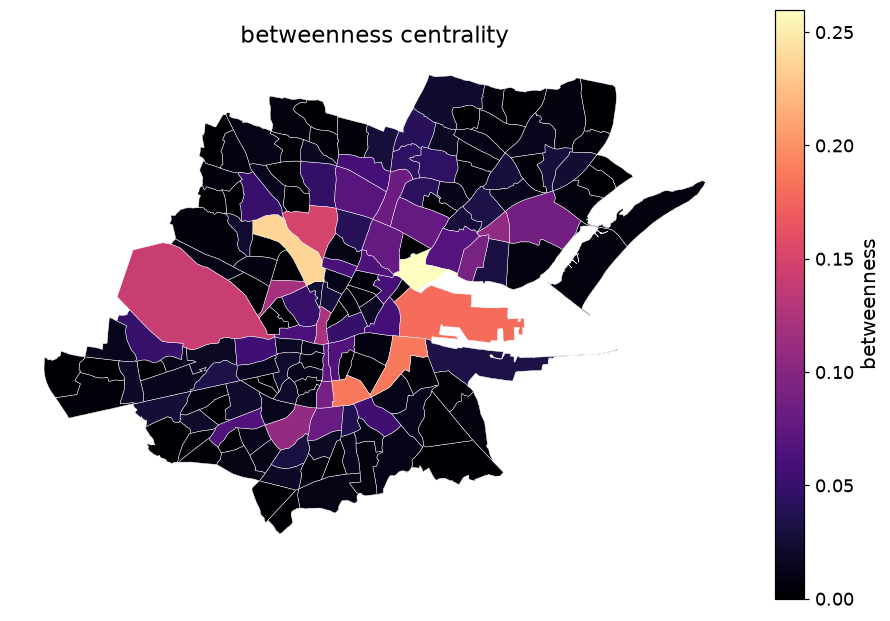

In [37]:
gdf["betweenness"] = list(nx.betweenness_centrality(G_ed).values())

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="betweenness", cmap="magma", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "betweenness"})
ax.set_axis_off()
ax.set_title("betweenness centrality")
plt.show()

lambda_1 = 4.37e-16  lambda_2 = 0.06089


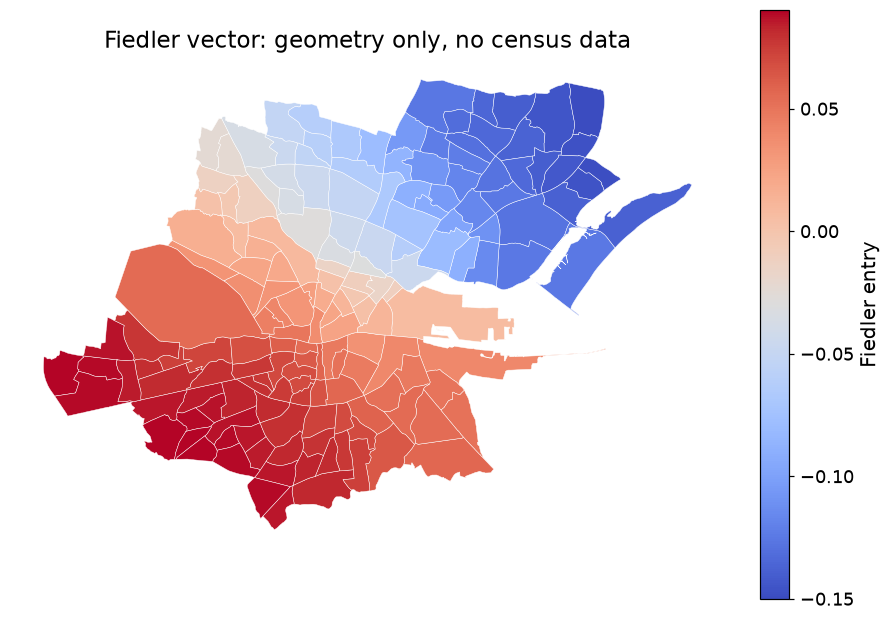

In [38]:
L_ed = nx.laplacian_matrix(G_ed, nodelist=range(len(gdf))).toarray().astype(float)
vals_ed, vecs_ed = eigh(L_ed)
gdf["fiedler"] = vecs_ed[:, 1]

print("lambda_1 =", f"{vals_ed[0]:.2e}", " lambda_2 =", f"{vals_ed[1]:.5f}")

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="fiedler", cmap="coolwarm", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "Fiedler entry"})
ax.set_axis_off()
ax.set_title(r"Fiedler vector: geometry only, no census data")
plt.show()

414 nodes, 909 edges


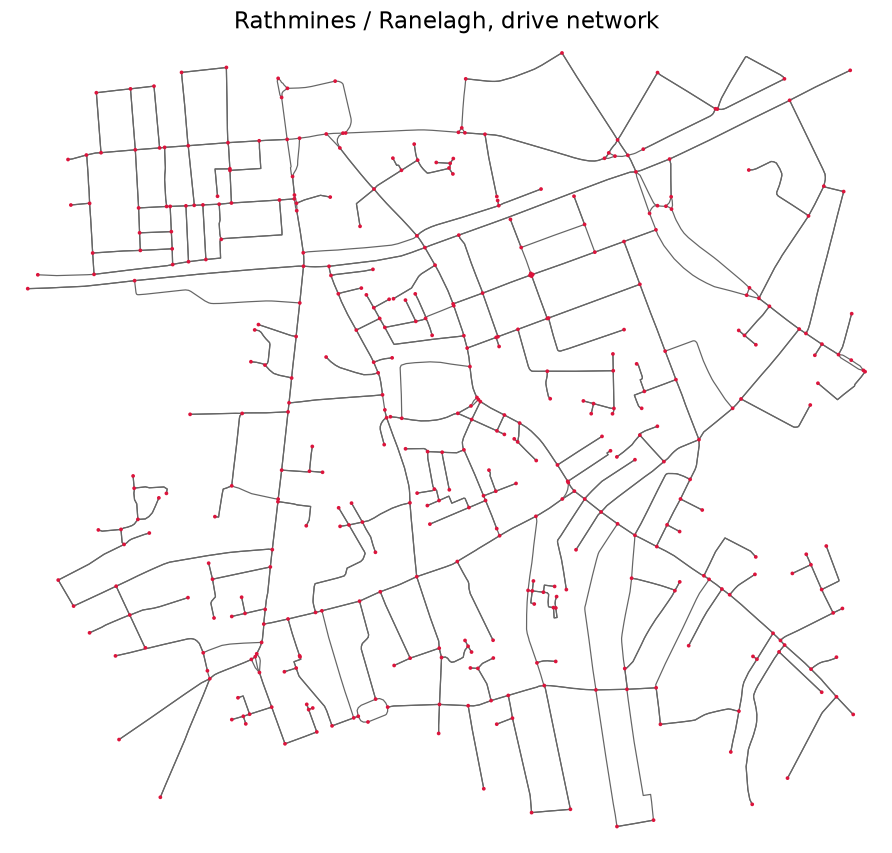

In [39]:
if HAVE_OSMNX:
    streets = ox.load_graphml(DATA / "streets.graphml")
    print(f"{streets.number_of_nodes()} nodes, {streets.number_of_edges()} edges")
    fig, ax = ox.plot_graph(streets, node_size=6, edge_linewidth=0.8,
                            bgcolor="white", node_color="crimson",
                            edge_color="0.4", figsize=(8, 8), show=False, close=False)
    ax.set_title("Rathmines / Ranelagh, drive network")
    plt.show()
else:
    print("skipped: osmnx did not import")

---
**Tuning note — section 7, the sigma sweep.**

`SIGMA` defaults to the median edge difference, 0.428 on this attribute. The sweep runs
10×, 1× and 0.4× that, and each panel prints its own λ₂.

0.4× rather than the 0.1× the sweep would ideally use: below about 0.3× the median,
enough edges are driven to numerical zero that the weighted graph separates into
components. λ₂ goes to zero, and `eigh` then returns an arbitrary vector out of a
degenerate null space. The map still renders and still looks like a clustering. At
0.2× `scipy.linalg.eigh(L, D)` gives up entirely — D is no longer positive definite.

This is why `weighted_fiedler` returns λ₂ and the cell prints it. A student who winds
`SIGMA` down to 0.05 will get a warning line rather than a confident wrong map, and
that is worth letting one of them discover out loud.

---

## 7 — Applied: weighted clustering (2:05)

$w_{ij} = \exp\!\left(-\dfrac{(x_i - x_j)^2}{2\sigma^2}\right)$ on the contiguity edges.
Similarity, not distance — with the sign the other way the map still looks plausible and is wrong.

In [40]:
from scipy.stats import skew

raw = gdf[ATTR].to_numpy(float)
print(f"skew of {ATTR}: {skew(raw):+.2f}")

# a log transform here would fight a distribution that is already symmetric
values = raw if abs(skew(raw)) < 1.0 else np.log1p(raw)
z = (values - values.mean()) / values.std(ddof=0)
print(f"standardised: mean {z.mean():+.2e}, sd {z.std(ddof=0):.3f}")

skew of pct_third_level: -0.03
standardised: mean +0.00e+00, sd 1.000


|z_i - z_j| across 462 contiguity edges
  10th percentile : 0.076
  25th percentile : 0.180
  50th percentile : 0.428
  75th percentile : 0.796
  90th percentile : 1.334
  max             : 2.211


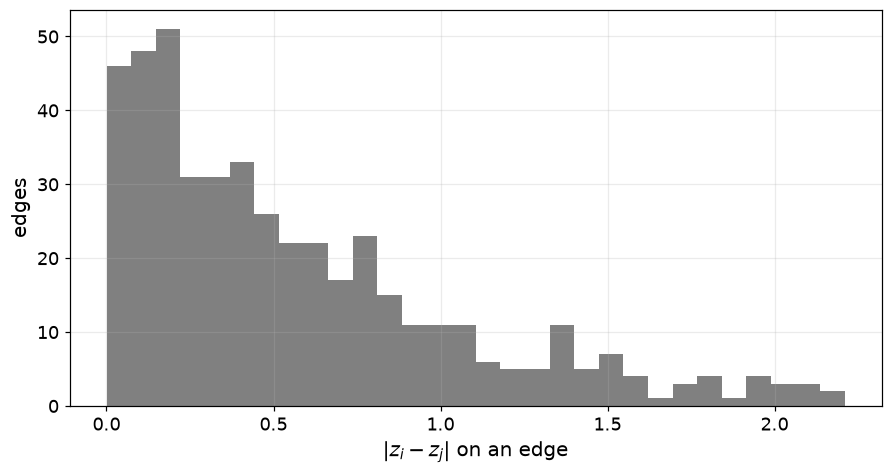

In [41]:
diffs = np.array([abs(z[i] - z[j]) for i, j in G_ed.edges()])
print(f"|z_i - z_j| across {len(diffs)} contiguity edges")
for q in (10, 25, 50, 75, 90):
    print(f"  {q:2d}th percentile : {np.percentile(diffs, q):.3f}")
print(f"  max             : {diffs.max():.3f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.hist(diffs, bins=30, color="0.5")
ax.set_xlabel(r"$|z_i - z_j|$ on an edge")
ax.set_ylabel("edges")
plt.show()

In [42]:
# ---------------------------------------------------------------------------
# CHANGE THIS AND RE-RUN. Everything below follows from it.
SIGMA = float(np.median(diffs))
# ---------------------------------------------------------------------------
print(f"SIGMA = {SIGMA:.3f}  (the median edge difference)")

SIGMA = 0.428  (the median edge difference)


edge weights: min 1.57e-06, median 0.607, max 1.000
lambda_2 = 5.433e-03


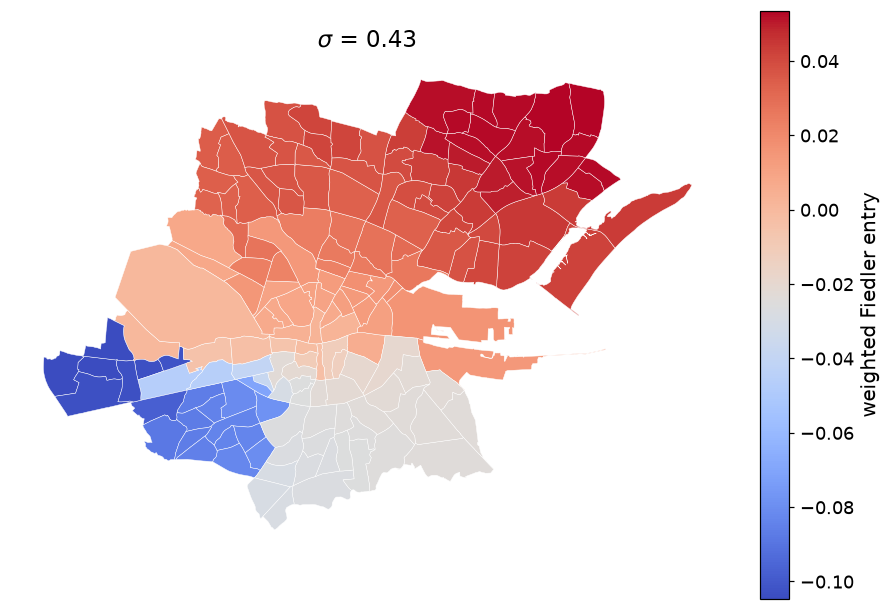

In [43]:
def weighted_fiedler(sigma):
    W = np.zeros((len(gdf), len(gdf)))
    for i, j in G_ed.edges():
        W[i, j] = W[j, i] = np.exp(-((z[i] - z[j]) ** 2) / (2 * sigma ** 2))
    Dw = np.diag(W.sum(axis=1))
    vals, vecs = eigh(Dw - W, Dw)
    return W, vecs[:, 1], vals[1]


W, f_weighted, lam2 = weighted_fiedler(SIGMA)
gdf["weighted"] = f_weighted

print(f"edge weights: min {W[W > 0].min():.2e}, median {np.median(W[W > 0]):.3f}, max {W[W > 0].max():.3f}")
print(f"lambda_2 = {lam2:.3e}")
if lam2 < 1e-9:
    # small sigma pushes whole edges to zero. Once the weighted graph has come
    # apart, lambda_2 is zero and the second eigenvector is an arbitrary vector
    # out of the null space: a map that looks fine and means nothing.
    print("  ^ numerically zero. The weighted graph has fallen into pieces; SIGMA is too small.")

fig, ax = plt.subplots(figsize=(8, 9))
gdf.plot(column="weighted", cmap="coolwarm", legend=True,
         edgecolor="white", linewidth=0.3, ax=ax,
         legend_kwds={"shrink": 0.6, "label": "weighted Fiedler entry"})
ax.set_axis_off()
ax.set_title(rf"$\sigma$ = {SIGMA:.2f}")
plt.show()

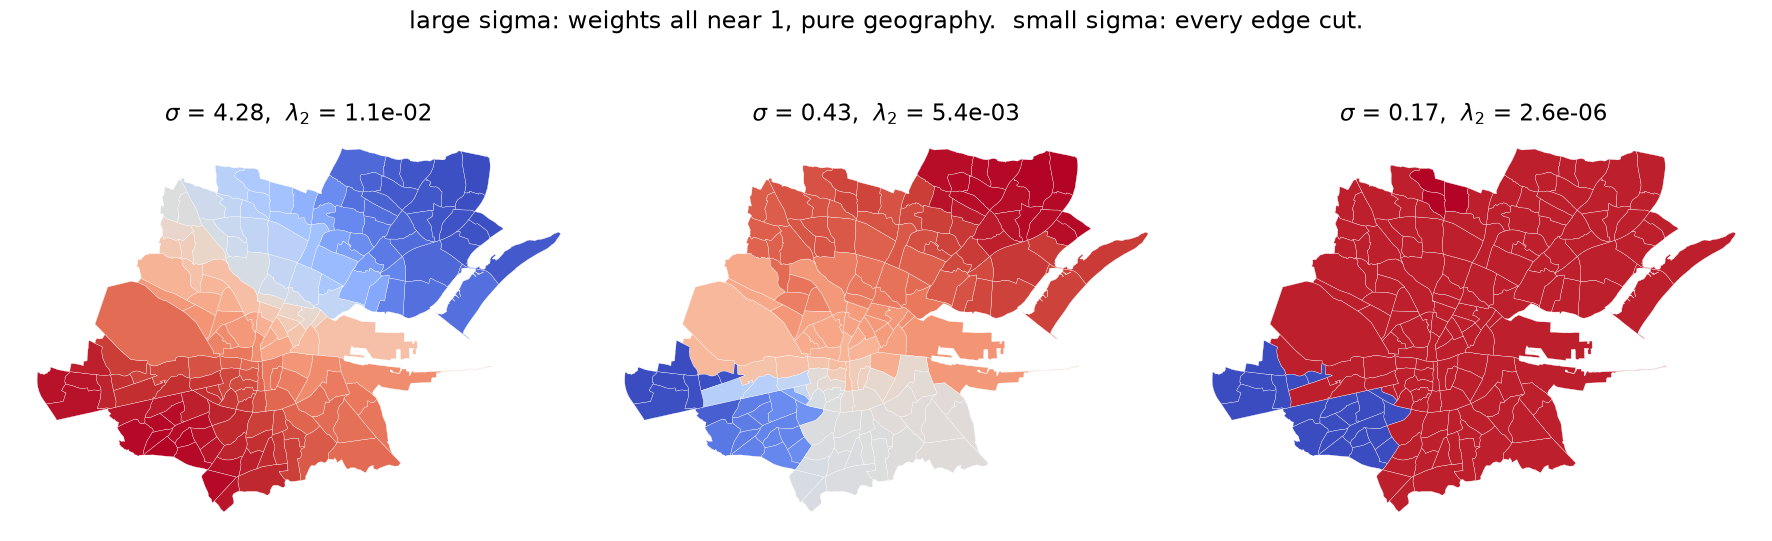

In [44]:
# 0.4 rather than 0.1: below about 0.3 x the median edge difference this
# particular graph separates into components and lambda_2 collapses to zero,
# which is what the printed values are there to show.
sigmas = [SIGMA * 10, SIGMA, SIGMA * 0.4]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, s in zip(axes, sigmas):
    _, f, lam = weighted_fiedler(s)
    gdf.assign(_f=f).plot(column="_f", cmap="coolwarm", ax=ax,
                          edgecolor="white", linewidth=0.2)
    ax.set_axis_off()
    ax.set_title(rf"$\sigma$ = {s:.2f},  $\lambda_2$ = {lam:.1e}")
fig.suptitle("large sigma: weights all near 1, pure geography.  small sigma: every edge cut.")
plt.show()

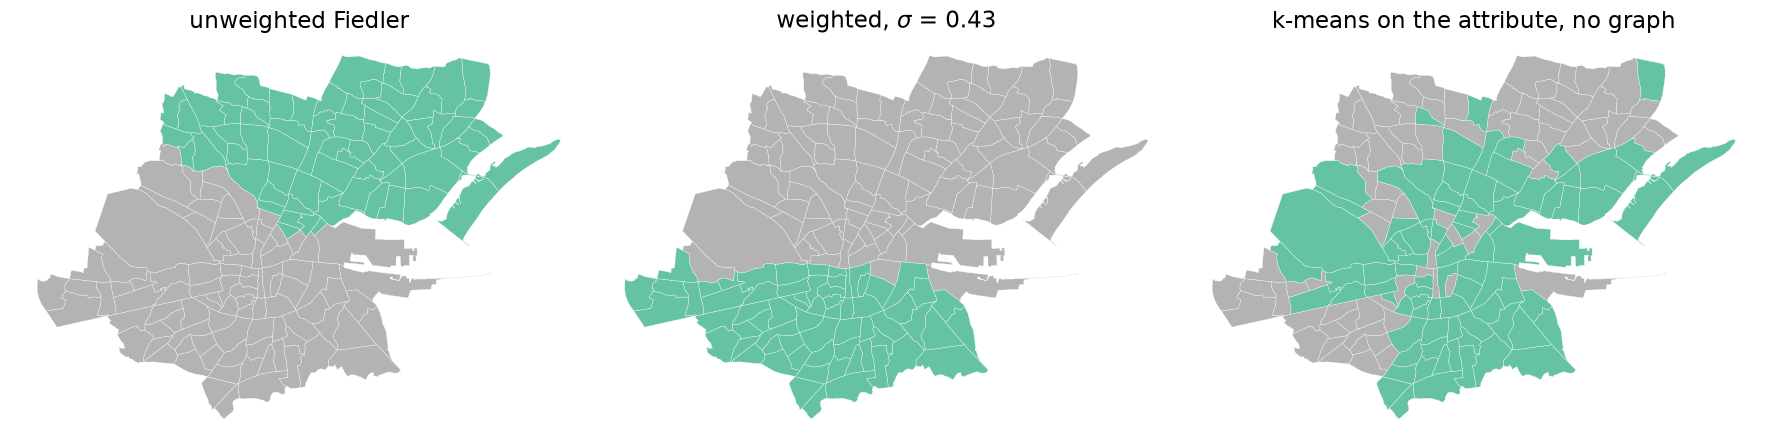

In [45]:
from sklearn.cluster import KMeans

labels_unweighted = (gdf["fiedler"].to_numpy() > 0).astype(int)
labels_weighted = (f_weighted > 0).astype(int)
labels_kmeans = KMeans(n_clusters=2, n_init=10, random_state=SEED).fit_predict(z.reshape(-1, 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, lab, title in [(axes[0], labels_unweighted, "unweighted Fiedler"),
                       (axes[1], labels_weighted, rf"weighted, $\sigma$ = {SIGMA:.2f}"),
                       (axes[2], labels_kmeans, "k-means on the attribute, no graph")]:
    gdf.assign(_l=lab).plot(column="_l", categorical=True, cmap="Set2", ax=ax,
                            edgecolor="white", linewidth=0.2)
    ax.set_axis_off()
    ax.set_title(title)
plt.show()

In [46]:
import pandas as pd

print(pd.crosstab(pd.Series(labels_unweighted, name="unweighted"),
                  pd.Series(labels_weighted, name="weighted")))

weighted     0   1
unweighted        
0            0  68
1           66  28


In [47]:
np.savez(
    DATA / "session1_state.npz",
    ed_names=gdf["ED_ENGLISH"].to_numpy(dtype=object),
    attribute=raw,
    z=z,
    sigma=SIGMA,
    fiedler=gdf["fiedler"].to_numpy(),
    labels_unweighted=labels_unweighted,
    labels_weighted=labels_weighted,
    labels_kmeans=labels_kmeans,
    allow_pickle=True,
)
print("wrote", (DATA / "session1_state.npz").resolve())

wrote /home/user/dist_net_finder/graph-workshop/data/session1_state.npz


## 8 — Braess (2:15)

Read this afterwards. Four nodes, 4000 drivers, travel times in minutes.

In [48]:
DRIVERS = 4000

# s -> v costs t/100 minutes with t drivers on it; v -> t is a flat 45.
# The lower route is the mirror image. Adding v -> w at zero cost gives every
# driver a strictly better response, and they all take it.
def travel_time(flow_upper, flow_lower):
    return flow_upper / 100 + 45, flow_lower / 100 + 45


without = travel_time(DRIVERS / 2, DRIVERS / 2)[0]
with_extra = DRIVERS / 100 + 0 + DRIVERS / 100

print(f"two routes, 2000 each  : {without:.0f} minutes")
print(f"plus a free v->w link  : {with_extra:.0f} minutes")
print(f"everyone loses {with_extra - without:.0f} minutes by gaining an option")

two routes, 2000 each  : 65 minutes
plus a free v->w link  : 80 minutes
everyone loses 15 minutes by gaining an option


In [49]:
def equilibrium(latency, demand, iters=2000):
    """User equilibrium by Frank-Wolfe in path-flow space. latency: {edge: (a, b)}
    for a travel time a + b * flow. Returns the common cost on the used routes."""
    g = nx.DiGraph(list(latency))
    if "s" not in g or "t" not in g or not nx.has_path(g, "s", "t"):
        return None
    paths = [tuple(p) for p in nx.all_simple_paths(g, "s", "t")]
    index = {e: k for k, e in enumerate(latency)}
    P = np.zeros((len(paths), len(latency)))
    for r, path in enumerate(paths):
        for e in zip(path, path[1:]):
            P[r, index[e]] = 1.0
    a = np.array([latency[e][0] for e in latency], float)
    b = np.array([latency[e][1] for e in latency], float)

    f = np.zeros(len(paths))
    f[0] = demand
    for _ in range(iters):
        x = P.T @ f
        target = np.zeros_like(f)
        target[np.argmin(P @ (a + b * x))] = demand      # all-or-nothing step
        d = P.T @ (target - f)
        denom = b @ (d * d)                              # exact line search: linear
        if denom <= 0:                                   # latencies make the
            gamma = 1.0                                  # Beckmann objective a
        else:                                            # quadratic in gamma
            gamma = min(1.0, max(0.0, -(d @ (a + b * x)) / denom))
        if gamma == 0.0:
            break
        f = f + gamma * (target - f)

    x = P.T @ f
    return float((P @ (a + b * x))[f > 1e-6].min())


def gadget(s_, v, w, m):
    return {(s_, v): (0.0, 0.01), (v, m): (45.0, 0.0),
            (s_, w): (45.0, 0.0), (w, m): (0.0, 0.01),
            (v, w): (0.0, 0.0)}


# two of the same trap in series
network = {**gadget("s", "v", "w", "m"), **gadget("m", "p", "q", "t")}
base = equilibrium(network, DRIVERS)

# Frank-Wolfe's tail is slow, so read these to about a tenth of a minute.
print(f"as built: {base:.2f} minutes\n")
for edge in list(network):
    trial = equilibrium({k: v for k, v in network.items() if k != edge}, DRIVERS)
    if trial is None:
        print(f"  close {str(edge):12s}  disconnects the network")
    else:
        print(f"  close {str(edge):12s}  {trial:7.2f}  ({trial - base:+6.2f})")

as built: 160.00 minutes

  close ('s', 'v')     165.00  ( +5.00)
  close ('v', 'm')     160.00  ( +0.00)
  close ('s', 'w')     160.00  ( +0.00)


  close ('w', 'm')     165.00  ( +5.00)


  close ('v', 'w')     144.96  (-15.04)
  close ('m', 'p')     165.00  ( +5.00)


  close ('p', 't')     160.00  ( +0.00)
  close ('m', 'q')     160.00  ( +0.00)
  close ('q', 't')     165.00  ( +5.00)
  close ('p', 'q')     144.96  (-15.04)
